Epoch 1/500, Train Loss: 1.218068, Val Loss: 0.510276
Epoch 50/500, Train Loss: 0.296393, Val Loss: 0.421817
Epoch 100/500, Train Loss: 0.053144, Val Loss: 0.518306
Early stopping at epoch 115, best val_loss=0.380985


/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/models/SurrogateNN.py:117: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  "std": param.data.std().item()


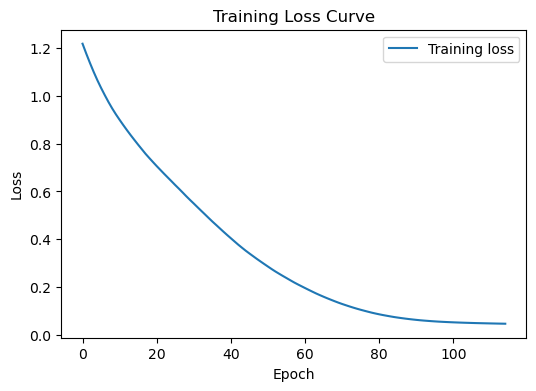

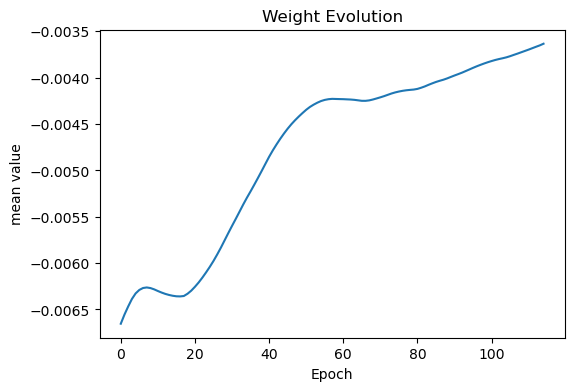

Using 3 dimensions.
Points before downsampling: 1000000
Points after downsampling: 1000000
Final grid shape: (1000000, 3)
Filtered 10896 candidates near decision boundary (|margin| < 0.2)
Excluded 989104 candidates from consideration
Final grid shape: (10896, 3)
Total number of points to evaluate: 9
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([0.09377275, 0.03878908, 0.409189  ]), 'score': 0.3992217367346196, 'dim': 3, 'predicted_y': 0.94199854}
{'method': 'PI', 'xi': 0.1, 'kappa': None, 'x': array([0.09377275, 0.03878908, 0.409189  ]), 'score': 0.23452722145439597, 'dim': 3, 'predicted_y': 0.94199854}
{'method': 'PI', 'xi': 0.3, 'kappa': None, 'x': array([0.09377275, 0.03878908, 0.409189  ]), 'score': 0.03874181146034003, 'dim': 3, 'predicted_y': 0.94199854}
{'method': 'EI', 'xi': 0.01, 'kappa': None, 'x': array([0.09377275, 0.03878908, 0.409189  ]), 'score': 0.0545770140051499, 'dim': 3, 'predicted_y': 0.94199854}
{'method': 'EI', 'xi': 0.1, 'kappa': None, 'x': array([0.09

In [ ]:
# flows/function1_flow.py

import sys, os
try:
    # Works when running as a normal Python script
    project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    # Fallback for Jupyter/IPython where __file__ is not defined
    project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

from data.BaseDataHandler import BaseDataHandler
from optimisation.BayesOptUtils import BayesOptUtils
from plotting.PlotUtils import PlotUtils
from Function3DataHandler import Function3DataHandler  # same folder
from models.SurrogateNN import SurrogateTrainer

# --- Data ---
dh = Function3DataHandler()
dh.add_weekly_updates()
df_sorted = dh.build_dataframe()
X, y = dh.inputs, dh.outputs

# --- Utilities ---
utils = BayesOptUtils()
plotter = PlotUtils()
trainer = SurrogateTrainer(input_dim=X.shape[1], lr=1e-3, epochs=500)

# --- Hyperparameters supplied here ---
xi_values = [0.01, 0.1, 0.3]
kappa_values = [1.0, 2.0, 3.0]
grid_sizes = [100, 200, 400]
methods = ['PI', 'EI', 'UCB']
apply_scaling = True
filter_mode = 'gp'

# --- Run flow ---
results = utils.run_flow(
    trainer, X, y,
    xi_values=xi_values,
    kappa_values=kappa_values,
    grid_sizes=grid_sizes,
    methods=methods,
    apply_scaling=apply_scaling,
    filter_mode=filter_mode
)


In [ ]:
# --- Loop over results and plot ---
for grid_size, (X_grid_filtered, mean, bounds, best, query_results, acq_maps) in results.items():
    print(f"\n=== Results for grid_size={grid_size} ===")

    # Extract candidates and labels
    candidates, labels = plotter.extract_candidates_and_labels(query_results, include_score=True)

    # Surrogate predictions plot
    plotter.plot_surrogate_generic(
        X_grid_filtered, mean,
        X_filtered=X_grid_filtered,
        bounds=bounds,
        candidates=candidates,
        candidate_labels=labels,
        title=f"Surrogate predictions (grid_size={grid_size})"
    )

    # Append candidates to BaseDataHandler and rebuild DataFrame
    cand_array, y_pred_array = dh.extract_candidate_arrays(query_results)
    dh.add_candidates(cand_array, y_pred_array)  # updates inputs/outputs/source_labels
    df_sorted = dh.build_dataframe()             # rebuild from updated arrays

    # Re-plot updated DataFrame
    plotter.plot_output_points(
        df_sorted,
        scale_factor=1.0,
        yield_scale_factor=100.0,
        source_marker='week-x',          # highlight all rows with source == 'week-x'
        source_color='red',
        source_marker_style='x'
    )
    # Print best candidate info
    print("Best candidate:", best)